In [83]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

train_transaction = pd.read_csv('ieee-fraud-detection/train_transaction.csv')
train_identity    = pd.read_csv('ieee-fraud-detection/train_identity.csv')
test_transaction  = pd.read_csv('ieee-fraud-detection/test_transaction.csv')
test_identity     = pd.read_csv('ieee-fraud-detection/test_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test  = test_transaction.merge(test_identity,  on='TransactionID', how='left')
test.columns = test.columns.str.replace('-', '_')

split = train['TransactionDT'].quantile(0.80)
tr  = train[train['TransactionDT'] <= split].copy()
val = train[train['TransactionDT'] >  split].copy()
print(f"tr {tr.shape} | val {val.shape} | test {test.shape}")

tr (472432, 434) | val (118108, 434) | test (506691, 433)


### Feature definition

In [84]:
delete_cols = ['id_29','V191','V196','V28','V241','V107','V117','V119','V120',
               'V113','V305','V88','V89','V27','V41','V65','V325','V327','V68','id_16','id_27']

cat_fea = ['ProductCD','card1','card2','card3','card4','card5','card6',
           'addr1','addr2','P_emaildomain','R_emaildomain','DeviceType','DeviceInfo']

for i in range(1, 10):
    if 'M'+str(i) not in delete_cols:
        cat_fea.append('M'+str(i))
for i in range(12, 39):
    if 'id_'+str(i) not in delete_cols:
        cat_fea.append('id_'+str(i))

num_fea = [f for f in train.columns
           if f not in ['TransactionID','isFraud'] + cat_fea + delete_cols]

### TransactionDT & TransactionAmt features

In [85]:
for df in [tr, val, test]:
    df['hour']          = (df['TransactionDT'] // 3600) % 24
    df['dayofweek']     = (df['TransactionDT'] // 86400) % 7
    df['day']           = df['TransactionDT']  // 86400
    df['hour_sin']      = np.sin(2 * np.pi * df['hour']      / 24)
    df['hour_cos']      = np.cos(2 * np.pi * df['hour']      / 24)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    df['log_amt']        = np.log1p(df['TransactionAmt'])
    df['amt_decimal']    = (df['TransactionAmt'] % 1).round(2).astype('category')
    df['amt_is_round']   = (df['TransactionAmt'] % 1 == 0).astype(np.int8)
    df['amt_last_digit'] = pd.Series(np.where(
        df['TransactionAmt'] % 1 == 0,
        df['TransactionAmt'].astype(int) % 10, -1
    ), index=df.index).astype('category')

num_fea.extend(['hour','dayofweek','day','hour_sin','hour_cos',
                'dayofweek_sin','dayofweek_cos','log_amt','amt_is_round'])
cat_fea.extend(['amt_decimal','amt_last_digit'])

### Log transform high-skew numeric features (|skew| > 10)

In [86]:
skew_series = tr[num_fea].select_dtypes(include=[np.number]).skew()
high_skew_cols = skew_series[skew_series.abs() > 10].index.tolist()
print(f"Log transforming {len(high_skew_cols)} features")

for col in high_skew_cols:
    for df in [tr, val, test]:
        df[col + '_log'] = np.log1p(df[col].clip(lower=0))
    num_fea.append(col + '_log')

Log transforming 195 features


### Bin D15

In [87]:
_, bin_edges = pd.qcut(tr['D15'], q=10, retbins=True, duplicates='drop')
for df in [tr, val, test]:
    df['D15_bin'] = pd.cut(df['D15'], bins=bin_edges, labels=False,
                           include_lowest=True).astype('category')
cat_fea.append('D15_bin')
print(f"D15 binned. Total so far — numeric: {len(num_fea)} | categorical: {len(cat_fea)}")

D15 binned. Total so far — numeric: 569 | categorical: 49


### Sort by TransactionDT

In [88]:
tr_s   = tr
val_s  = val
test_s = test

# base_df for test aggregations: all labeled data (train + val)
test_base = pd.concat([tr_s, val_s,test_s], ignore_index=True)
val_base = pd.concat([tr_s, val_s], ignore_index=True)

cat_fea = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2',
           'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo', 'M1', 'M2', 'M3', 'M4',
           'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_17', 'id_18',
           'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_28',
           'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
           'amt_decimal', 'amt_last_digit', 'D15_bin']

### uid_ProductCD_freq_before — per-user ProductCD prior usage count

In [ ]:
# ── build user_id1 ────────────────────────────────────────────────────────────
for df in [tr_s, val_s, test_s]:
    df['D1_norm']  = (df['TransactionDT'] // 86400).astype(int) - df['D1'].fillna(-1).astype(int)
    df['user_id1'] = (df['card1'].astype(str) + '_' +
                      df['addr1'].astype(str) + '_' +
                      df['D1_norm'].astype(str))

# ── global lookup: (user_id1, ProductCD) count across all splits ──────────────
all_combined = pd.concat([tr_s, val_s, test_s], ignore_index=True)
global_history = all_combined.groupby(['user_id1', 'ProductCD']).size()

# ── map freq back to each split, subtract 1 so a row doesn't count itself ─────
# 0 = this (user, ProductCD) only appears once in the full dataset
# N = appeared N other times across tr+val+test
for df in [tr_s, val_s, test_s]:
    keys = pd.MultiIndex.from_arrays([df['user_id1'], df['ProductCD']])
    df['uid_ProductCD_freq'] = (global_history.reindex(keys).fillna(0).astype(int) - 1).clip(lower=0).values

num_fea.append('uid_ProductCD_freq')
print("uid_ProductCD_freq added.")
print(f"  tr   zeros: {(tr_s['uid_ProductCD_freq']  == 0).mean()*100:.1f}%  max: {tr_s['uid_ProductCD_freq'].max()}")
print(f"  val  zeros: {(val_s['uid_ProductCD_freq'] == 0).mean()*100:.1f}%  max: {val_s['uid_ProductCD_freq'].max()}")
print(f"  test zeros: {(test_s['uid_ProductCD_freq']== 0).mean()*100:.1f}%  max: {test_s['uid_ProductCD_freq'].max()}")

In [100]:
 (all_combined.groupby(['user_id1', col])
                                .size()
                                .rename('cnt')
                                .reset_index())

,user_id1,R_emaildomain,cnt
0,10000_184.0_-37,aim.com,0
1,10000_184.0_-37,anonymous.com,0
2,10000_184.0_-37,aol.com,0
3,10000_184.0_-37,att.net,0
4,10000_184.0_-37,bellsouth.net,0
...,...,...,...
23226655,9999_441.0_81,yahoo.com.mx,0
23226656,9999_441.0_81,yahoo.de,0
23226657,9999_441.0_81,yahoo.es,0
23226658,9999_441.0_81,yahoo.fr,0


In [103]:
user_val_cnt = (all_combined.groupby(['user_id1', col])
                                .size()
                                .rename('cnt')
                                .reset_index())

    # ── n_distinct: number of unique values per user ──────────────────────────
n_distinct_map = user_val_cnt.groupby('user_id1')['cnt'].count()
n_distinct_map

user_id1
10000_184.0_-37    60
10001_204.0_267    60
10002_428.0_367    60
10002_nan_317      60
10003_nan_90       60
                   ..
9998_512.0_352     60
9999_330.0_13      60
9999_330.0_21      60
9999_330.0_35      60
9999_441.0_81      60
Name: cnt, Length: 387111, dtype: int64

In [107]:
tr['n_distinct_P_emaildomain']

0         0
1         1
2         1
3         1
4         1
         ..
472427    1
472428    1
472429    1
472430    1
472431    1
Name: n_distinct_P_emaildomain, Length: 472432, dtype: int64

### Per-user value profile features — is_mode_R_emaildomain, n_distinct_P_emaildomain, n_distinct_R_emaildomain

In [114]:
all_combined = pd.concat([tr_s, val_s, test_s], ignore_index=True)

for col in ['ProductCD', 'P_emaildomain', 'R_emaildomain']:
    # ── 1. n_distinct: how many unique values this user has used ──────────────
    # observed=True: prevents categorical cross-product (would give nunique=total_cats everywhere)
    n_distinct_map = all_combined.groupby('user_id1', observed=True)[col].nunique()
    for df in [tr_s, val_s, test_s]:
        df[f'n_distinct_{col}'] = df['user_id1'].map(n_distinct_map).fillna(1).astype(int)
    num_fea.append(f'n_distinct_{col}')

    # ── 2. mode_cnt: frequency of user's most-used value ─────────────────────
    user_val_cnt = (all_combined.groupby(['user_id1', col], observed=True)
                                .size()
                                .reset_index(name='cnt'))
    best = (user_val_cnt.sort_values('cnt', ascending=False)
                        .drop_duplicates('user_id1')
                        .set_index('user_id1'))
    mode_val_map = best[col]
    mode_cnt_map = best['cnt']

    for df in [tr_s, val_s, test_s]:
        df[f'mode_cnt_{col}'] = df['user_id1'].map(mode_cnt_map).fillna(0).astype(int)
    num_fea.append(f'mode_cnt_{col}')

    # ── 3. is_mode: current value == user's most frequent value ──────────────
    for df in [tr_s, val_s, test_s]:
        df[f'is_mode_{col}'] = (df[col] == df['user_id1'].map(mode_val_map)).astype(np.int8)
    num_fea.append(f'is_mode_{col}')

new_feats = [f for col in ['ProductCD', 'P_emaildomain', 'R_emaildomain']
             for f in [f'n_distinct_{col}', f'mode_cnt_{col}', f'is_mode_{col}']]
print('Added:', new_feats)
for f in new_feats:
    print(f'  {f}:  tr nunique={tr_s[f].nunique()}  mean={tr_s[f].mean():.3f}'
          f'  | val nunique={val_s[f].nunique()}  mean={val_s[f].mean():.3f}')


Added: ['n_distinct_ProductCD', 'mode_cnt_ProductCD', 'is_mode_ProductCD', 'n_distinct_P_emaildomain', 'mode_cnt_P_emaildomain', 'is_mode_P_emaildomain', 'n_distinct_R_emaildomain', 'mode_cnt_R_emaildomain', 'is_mode_R_emaildomain']
  n_distinct_ProductCD:  tr nunique=4  mean=1.120  | val nunique=4  mean=1.079
  mode_cnt_ProductCD:  tr nunique=140  mean=12.119  | val nunique=136  mean=31.439
  is_mode_ProductCD:  tr nunique=2  mean=0.972  | val nunique=2  mean=0.987
  n_distinct_P_emaildomain:  tr nunique=14  mean=1.554  | val nunique=14  mean=1.440
  mode_cnt_P_emaildomain:  tr nunique=116  mean=7.988  | val nunique=114  mean=8.305
  is_mode_P_emaildomain:  tr nunique=2  mean=0.734  | val nunique=2  mean=0.734
  n_distinct_R_emaildomain:  tr nunique=13  mean=0.599  | val nunique=12  mean=0.435
  mode_cnt_R_emaildomain:  tr nunique=71  mean=1.808  | val nunique=68  mean=20.626
  is_mode_R_emaildomain:  tr nunique=2  mean=0.195  | val nunique=2  mean=0.171


### groupby_agg_features

Computes per-entity aggregate statistics from `base_df` and merges them into `target_df`.

- `base_df`  — source of aggregation (tr_s for train/val; test_base for test)
- `target_df` — DataFrame to add features to (modified in-place)
- `col`      — groupby key (entity column)
- `valueset` — non-empty list of numeric columns to aggregate

For each value column, 8 stats are added: `cnt`, `sum`, `avg`, `min`, `max`, `p25`, `p50`, `p75`.

In [109]:
def groupby_agg_features(base_df, target_df, col, valueset):
    """
    Compute per-entity aggregate stats from base_df and join to target_df.

    valueset : non-empty list of numeric columns to aggregate.
    Modifies target_df in-place; returns list of new feature names.
    """
    agg_parts = []
    new_feats = []

    for val in valueset:
        g = base_df.groupby(col)[val]
        part = pd.concat([
            g.count()          .rename(f"{col}_{val}_cnt"),
            g.sum()            .rename(f"{col}_{val}_sum"),
            g.mean()           .rename(f"{col}_{val}_avg"),
            g.min()            .rename(f"{col}_{val}_min"),
            g.max()            .rename(f"{col}_{val}_max"),
            g.quantile(0.25)   .rename(f"{col}_{val}_p25"),
            g.median()         .rename(f"{col}_{val}_p50"),
            g.quantile(0.75)   .rename(f"{col}_{val}_p75"),
        ], axis=1)
        agg_parts.append(part)
        new_feats.extend(part.columns.tolist())

    agg_df  = pd.concat(agg_parts, axis=1).reset_index()   # col becomes a regular column
    merged  = target_df[[col]].reset_index().merge(agg_df, on=col, how='left').set_index('index')

    for feat in new_feats:
        target_df[feat] = merged[feat]

    return new_feats


# ── columns to aggregate per entity ──────────────────────────────────────────
n = 256  # unique-value threshold for native category dtype
# ─────────────────────────────────────────────────────────────────────────────

### Categorical encoding + groupby aggregate features

- Unique values < 128  → native LightGBM category dtype
- Unique values ≥ 128  → `groupby_agg_features` on each column in `valueset`

In [110]:
groupby_features = []
for col in list(cat_fea):
    if col in ["card1","card2","addr1","P_emaildomain","card5"]:
        print(col)
        valueset = ['TransactionAmt','C13','dist1']
        feats = groupby_agg_features(test_base,      tr_s,   col, valueset)
        groupby_agg_features(test_base,      val_s,  col, valueset)
        groupby_agg_features(test_base, test_s, col, valueset)
        groupby_features.extend(feats)
        if col not in ['card5','P_emaildomain']:
            cat_fea.remove(col)
        else:
            tr_cats = tr_s[col].astype('category').cat.categories
            for df in [tr_s, val_s, test_s]:
                df[col] = pd.Categorical(df[col], categories=tr_cats)
        print(f"  {col} done — {len(feats)} features")

    else: 
        cur_unique = tr_s[col].nunique()
        if cur_unique < n:
            tr_cats = tr_s[col].astype('category').cat.categories
            for df in [tr_s, val_s, test_s]:
                df[col] = pd.Categorical(df[col], categories=tr_cats)
        else:
            print(col)
            valueset = ['TransactionAmt']
            feats = groupby_agg_features(test_base,      tr_s,   col, valueset)
            groupby_agg_features(test_base,      val_s,  col, valueset)
            groupby_agg_features(test_base , test_s, col, valueset)
            groupby_features.extend(feats)
            cat_fea.remove(col)
            print(f"  {col} done — {len(feats)} features")

card5
  card5 done — 24 features
P_emaildomain
  P_emaildomain done — 24 features


In [111]:
features = num_fea + cat_fea + groupby_features
print(f"Total features: {len(features)} | numeric: {len(num_fea)} | categorical: {len(cat_fea)} | groupby: {len(groupby_features)}")
print(f"Categorical features: {cat_fea}")

Total features: 668 | numeric: 579 | categorical: 41 | groupby: 48
Categorical features: ['ProductCD', 'card3', 'card4', 'card5', 'card6', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_17', 'id_18', 'id_22', 'id_23', 'id_24', 'id_26', 'id_28', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'amt_decimal', 'amt_last_digit', 'D15_bin']


In [112]:
tr_s['card1'].astype("string") +"_"+ tr_s['card2'].astype("string")

0                <NA>
1          2755_404.0
2          4663_490.0
3         18132_567.0
4          4497_514.0
             ...     
472427    15484_418.0
472428    17188_321.0
472429    16659_170.0
472430     7919_194.0
472431    13749_321.0
Length: 472432, dtype: string

### Train model

In [113]:
X_tr   = tr_s[features].copy()
X_val  = val_s[features].copy()
X_test = test_s[features].copy()
y_tr   = tr_s['isFraud']
y_val  = val_s['isFraud']

model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=256,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    eval_names=["train", "valid"],
    categorical_feature=cat_fea,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Fatal] Feature (n_distinct_P_emaildomain) appears more than one time.


LightGBMError: Feature (n_distinct_P_emaildomain) appears more than one time.

### Validation performance

In [95]:
val_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_pred)
print(f"model_v2 AUC : 0.9257  (label_fre_3, global freq — leaked)")
print(f"model_v3 AUC : 0.9127  (rolling count — leak-free)")
print(f"model_v4 AUC : {auc:.4f} (groupby aggregate)")
print(f"Diff vs v2   : {auc - 0.9257:+.4f}")

model_v2 AUC : 0.9257  (label_fre_3, global freq — leaked)
model_v3 AUC : 0.9127  (rolling count — leak-free)
model_v4 AUC : 0.9310 (groupby aggregate)
Diff vs v2   : +0.0053


### Confusion matrix

Sweep thresholds and report precision / recall / F1 alongside the matrix at the best-F1 threshold.

Best-F1 threshold : 0.2524  | precision 0.6544  recall 0.5116  F1 0.5742
thr=0.1000 | precision=0.4425 recall=0.6319 F1=0.5205
thr=0.2000 | precision=0.5939 recall=0.5426 F1=0.5671
thr=0.3000 | precision=0.6984 recall=0.4850 F1=0.5725
thr=0.5000 | precision=0.8185 recall=0.4006 F1=0.5379
thr=0.2524 | precision=0.6544 recall=0.5116 F1=0.5742

Confusion matrix @ thr=0.2524
            pred_neg  pred_pos
actual_neg    112946      1098
actual_pos      1985      2079

TN=112946  FP=1098  FN=1985  TP=2079
Fraud catch rate (recall) : 0.5116
False-alarm rate          : 0.0096


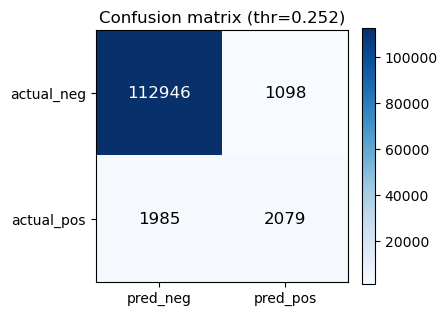

In [80]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, precision_recall_curve
import matplotlib.pyplot as plt

prec, rec, thr = precision_recall_curve(y_val, val_pred)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = f1[:-1].argmax()
best_thr = thr[best_idx]
print(f"Best-F1 threshold : {best_thr:.4f}  | precision {prec[best_idx]:.4f}  recall {rec[best_idx]:.4f}  F1 {f1[best_idx]:.4f}")

for t in [0.1, 0.2, 0.3, 0.5, best_thr]:
    y_hat = (val_pred >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_val, y_hat, average='binary', zero_division=0)
    print(f"thr={t:.4f} | precision={p:.4f} recall={r:.4f} F1={f:.4f}")

y_hat = (val_pred >= best_thr).astype(int)
cm = confusion_matrix(y_val, y_hat)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion matrix @ thr={best_thr:.4f}")
print(pd.DataFrame(cm,
                   index=['actual_neg','actual_pos'],
                   columns=['pred_neg','pred_pos']))
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Fraud catch rate (recall) : {tp/(tp+fn):.4f}")
print(f"False-alarm rate          : {fp/(fp+tn):.4f}")

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(['pred_neg', 'pred_pos'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['actual_neg', 'actual_pos'])
ax.set_title(f'Confusion matrix (thr={best_thr:.3f})')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

### Feature importance

In [96]:
importance = (pd.DataFrame({
    'feature':    features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True))

print("=== Top 40 ===")
print(importance.head(40).to_string(index=False))

print("\n=== Groupby engineered features ===")
print(importance[importance['feature'].isin(groupby_features)].to_string(index=False))

=== Top 40 ===
                 feature  importance
             amt_decimal        2279
          TransactionAmt        1061
           TransactionDT        1012
                   id_31         635
                     C13         582
         card1_dist1_avg         569
                     D15         521
           card1_C13_avg         511
card1_TransactionAmt_max         484
                   dist1         480
         card1_dist1_max         460
card2_TransactionAmt_max         455
card1_TransactionAmt_avg         439
           card1_C13_max         433
         card1_dist1_p75         430
                      C1         428
                      D2         395
                      D4         392
card1_TransactionAmt_min         388
                     D10         385
           addr1_C13_avg         383
         addr1_dist1_max         379
           P_emaildomain         375
           addr1_C13_max         351
           card2_C13_avg         350
addr1_TransactionAmt_ma

### Generate submission

In [82]:
test_pred = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'TransactionID': test_s['TransactionID'].values,
    'isFraud':       test_pred
})

test_original_order = test_transaction['TransactionID'].values
submission = submission.set_index('TransactionID').loc[test_original_order].reset_index()

submission.to_csv('submission_v7.csv', index=False)
print(f"Saved: {submission.shape}")
print(submission['isFraud'].describe().round(4))

Saved: (506691, 2)
count    506691.0000
mean          0.0291
std           0.1154
min           0.0002
25%           0.0021
50%           0.0044
75%           0.0110
max           0.9965
Name: isFraud, dtype: float64
